In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Task 2: Exploratory Data Analysis

**Dataset overview · Temporal coverage · Data quality · Coverage gaps**

In [2]:
# Load enriched data from Task 1
df = pd.read_csv('../data/processed/ethiopia_fi_enriched_data.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
df['year'] = df['observation_date'].dt.year

# --- 1. DATASET OVERVIEW ---
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nTotal records: {len(df)}")

print("\n--- By record_type ---")
print(df['record_type'].value_counts().to_string())

print("\n--- By pillar ---")
print(df['pillar'].value_counts(dropna=False).to_string())
# Fill NaN pillar for events for display
print("\n--- By source_type ---")
print(df['source_type'].value_counts(dropna=False).to_string())


DATASET OVERVIEW

Total records: 44

--- By record_type ---
record_type
observation    30
event          11
target          3

--- By pillar ---
pillar
ACCESS           16
USAGE            11
NaN              11
GENDER            5
AFFORDABILITY     1

--- By source_type ---
source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
NaN            1


## Temporal coverage: which years have data for which indicators?

We build a matrix of **observation + target** records by year and indicator (observation/target only; events are point-in-time).

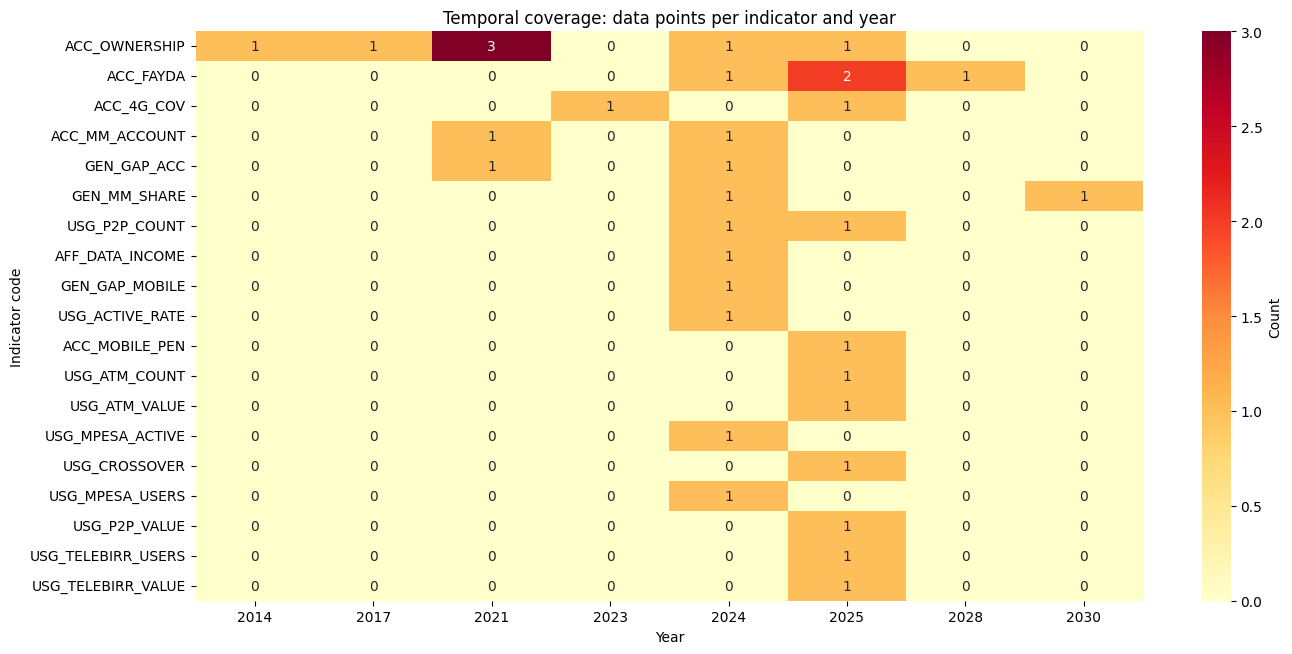

In [3]:
# Temporal coverage: observations + targets (exclude events)
obs_target = df[df['record_type'].isin(['observation', 'target'])].copy()
obs_target = obs_target.dropna(subset=['year', 'indicator_code'])
# Build year x indicator matrix (count of records)
cov = obs_target.pivot_table(
    index='indicator_code',
    columns='year',
    values='record_id',
    aggfunc='count',
    fill_value=0
)
# Sort by total coverage (descending)
cov['_total'] = cov.sum(axis=1)
cov = cov.sort_values('_total', ascending=False).drop(columns=['_total'])
# Heatmap
plt.figure(figsize=(14, max(6, len(cov) * 0.35)))
sns.heatmap(cov, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Temporal coverage: data points per indicator and year')
plt.xlabel('Year')
plt.ylabel('Indicator code')
plt.tight_layout()
plt.show()

## Data quality: distribution of confidence levels

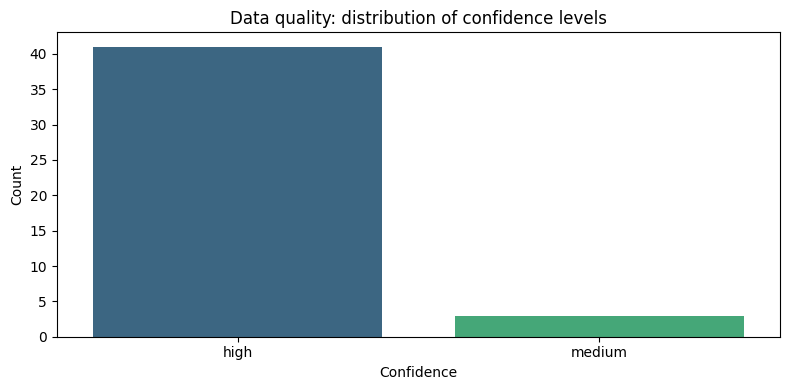

In [4]:
# Confidence: only for rows that have it (events/observations)
has_conf = df.dropna(subset=['confidence'])
plt.figure(figsize=(8, 4))
sns.countplot(data=has_conf, x='confidence', hue='confidence', legend=False, palette='viridis')
plt.title('Data quality: distribution of confidence levels')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Gaps: which indicators have sparse coverage?

Indicators with few observations or few distinct years are flagged as sparse.

In [5]:
# Sparse coverage: observations only, by indicator
obs_only = df[(df['record_type'] == 'observation')].dropna(subset=['indicator_code', 'year'])
by_ind = obs_only.groupby('indicator_code').agg(
    n_obs=('record_id', 'count'),
    n_years=('year', 'nunique')
).reset_index()
by_ind = by_ind.sort_values('n_obs')
# Flag sparse: <= 3 observations or <= 2 distinct years
by_ind['sparse'] = (by_ind['n_obs'] <= 3) | (by_ind['n_years'] <= 2)
print("--- Coverage by indicator (observations only) ---")
print(by_ind.to_string(index=False))
print("\n--- Indicators with SPARSE coverage (≤3 obs or ≤2 years) ---")
sparse = by_ind[by_ind['sparse']][['indicator_code', 'n_obs', 'n_years']]
print(sparse.to_string(index=False) if len(sparse) else "None")

--- Coverage by indicator (observations only) ---
    indicator_code  n_obs  n_years  sparse
    ACC_MOBILE_PEN      1        1    True
   AFF_DATA_INCOME      1        1    True
    GEN_GAP_MOBILE      1        1    True
     USG_CROSSOVER      1        1    True
     USG_ATM_VALUE      1        1    True
     USG_ATM_COUNT      1        1    True
   USG_ACTIVE_RATE      1        1    True
      GEN_MM_SHARE      1        1    True
   USG_MPESA_USERS      1        1    True
  USG_MPESA_ACTIVE      1        1    True
USG_TELEBIRR_USERS      1        1    True
     USG_P2P_VALUE      1        1    True
USG_TELEBIRR_VALUE      1        1    True
    ACC_MM_ACCOUNT      2        2    True
        ACC_4G_COV      2        2    True
       GEN_GAP_ACC      2        2    True
     USG_P2P_COUNT      2        2    True
         ACC_FAYDA      3        2    True
     ACC_OWNERSHIP      6        4   False

--- Indicators with SPARSE coverage (≤3 obs or ≤2 years) ---
    indicator_code  n_obs  n

---
# Access Analysis

**Focus:** Account ownership (ACC_OWNERSHIP) — trajectory, growth rates, disaggregation, and 2021–2024 slowdown.

## 1. Account ownership trajectory (2014–2024)

*Note: Findex survey data in this dataset start in 2014; 2011 is not present.*

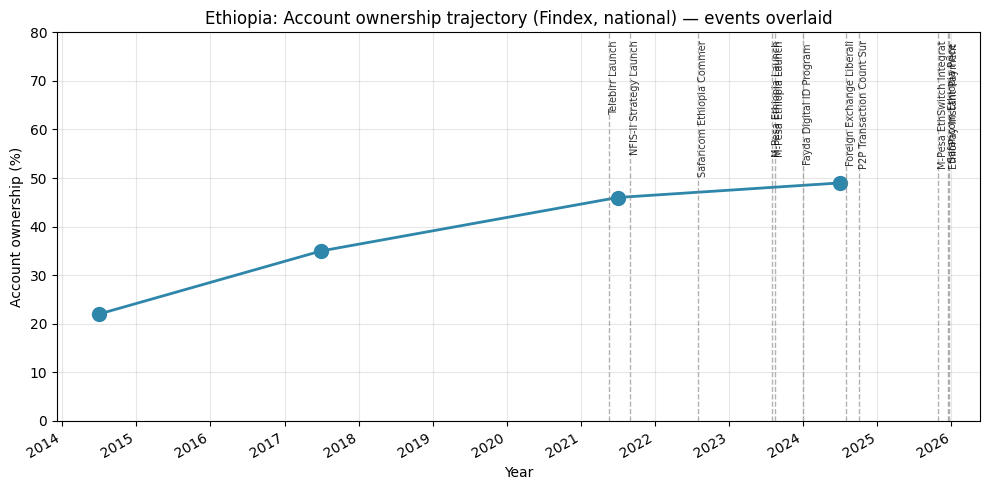


Data points:  year  value_numeric
 2014           22.0
 2017           35.0
 2021           46.0
 2024           49.0


In [6]:
# ACC_OWNERSHIP: national "all" only for clean time series (observations for trajectory 2014-2024)
acc = df[(df['indicator_code'] == 'ACC_OWNERSHIP') & (df['record_type'] == 'observation')].copy()
acc = acc[acc['gender'].fillna('all').astype(str).str.lower() == 'all'].dropna(subset=['year', 'value_numeric'])
acc = acc.sort_values('year').drop_duplicates(subset=['year'], keep='first')
acc = acc[(acc['year'] >= 2014) & (acc['year'] <= 2024)]
acc_dates = pd.to_datetime(acc['year'].astype(int).astype(str) + '-06-30')

# Events for overlay
ev = df[df['record_type'] == 'event'].copy()
ev = ev.dropna(subset=['observation_date'])
ev['observation_date'] = pd.to_datetime(ev['observation_date'], errors='coerce')
ev = ev.dropna(subset=['observation_date'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(acc_dates, acc['value_numeric'], marker='o', linewidth=2, markersize=10, color='#2e86ab', label='Account ownership')
ymin, ymax = 0, 80
ax.set_ylim(ymin, ymax)
for _, r in ev.iterrows():
    ax.axvline(x=r['observation_date'], color='gray', linestyle='--', alpha=0.6, linewidth=1)
    label = (r.get('indicator') or r.get('notes') or '')[:25]
    if isinstance(label, str) and label:
        ax.text(r['observation_date'], ymax * 0.98, label, rotation=90, fontsize=7, va='top', ha='left', alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Account ownership (%)')
ax.set_title("Ethiopia: Account ownership trajectory (Findex, national) — events overlaid")
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()
print("\nData points:", acc[['year', 'value_numeric']].to_string(index=False))

## 2. Growth rates between survey years

--- Growth between survey years ---
 from_year  to_year  pp_change  pct_change
      2014     2017       13.0   59.090909
      2017     2021       11.0   31.428571
      2021     2024        3.0    6.521739


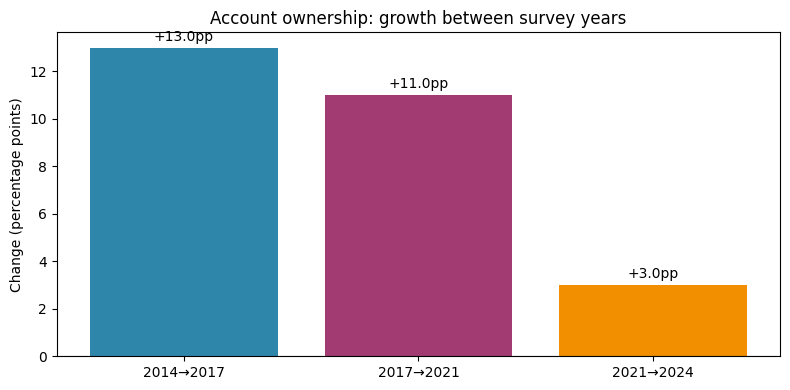

In [7]:
# Growth between consecutive survey years (pp = percentage points)
acc_sorted = acc.sort_values('year').reset_index(drop=True)
growth = []
for i in range(1, len(acc_sorted)):
    y0, y1 = acc_sorted.iloc[i-1]['year'], acc_sorted.iloc[i]['year']
    v0, v1 = acc_sorted.iloc[i-1]['value_numeric'], acc_sorted.iloc[i]['value_numeric']
    pp = v1 - v0
    pct = (v1 - v0) / v0 * 100 if v0 else None
    growth.append({'from_year': int(y0), 'to_year': int(y1), 'pp_change': pp, 'pct_change': pct})
growth_df = pd.DataFrame(growth)
print("--- Growth between survey years ---")
print(growth_df.to_string(index=False))

# Visualize growth rates (pp)
if len(growth_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    labels = [f"{int(r['from_year'])}→{int(r['to_year'])}" for _, r in growth_df.iterrows()]
    bars = ax.bar(labels, growth_df['pp_change'], color=['#2e86ab', '#a23b72', '#f18f01'])
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('Change (percentage points)')
    ax.set_title('Account ownership: growth between survey years')
    for bar, val in zip(bars, growth_df['pp_change']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3 if val >= 0 else val - 0.8, f'{val:+.1f}pp', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

## 3. Disaggregated analysis

### 3a. Gender gap (male vs female ownership)

We have gender-disaggregated ACC_OWNERSHIP for 2021 and a derived gender gap (GEN_GAP_ACC) for 2021 and 2024.

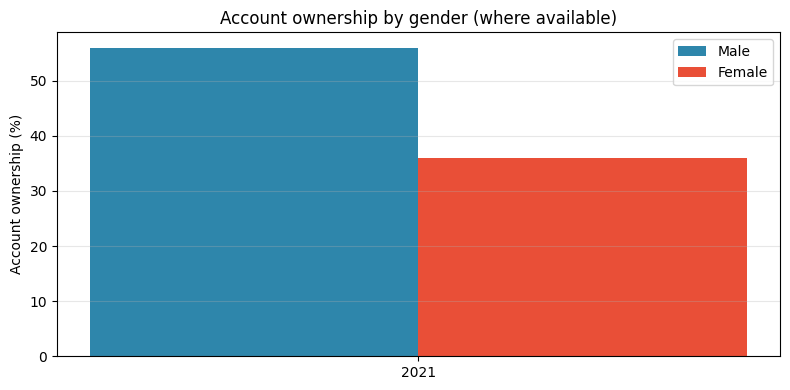


Gender-disaggregated ownership:
gender  female  male
year                
2021      36.0  56.0

Gender gap (GEN_GAP_ACC, percentage points, lower = better):
 year  value_numeric
 2021           20.0
 2024           18.0


In [8]:
# Gender: ACC_OWNERSHIP by gender (observations only)
acc_g = df[(df['indicator_code'] == 'ACC_OWNERSHIP') & (df['record_type'] == 'observation')].copy()
acc_g = acc_g[acc_g['gender'].notna() & (acc_g['gender'].str.lower() != 'all')]
acc_g = acc_g[['year', 'gender', 'value_numeric']].dropna().sort_values(['year', 'gender'])

if len(acc_g) > 0:
    pivot_g = acc_g.pivot(index='year', columns='gender', values='value_numeric')
    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(pivot_g))
    w = 0.35
    ax.bar([i - w/2 for i in x], pivot_g.get('male', pd.Series(dtype=float)), width=w, label='Male', color='#2e86ab')
    ax.bar([i + w/2 for i in x], pivot_g.get('female', pd.Series(dtype=float)), width=w, label='Female', color='#e94f37')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_g.index.astype(int))
    ax.set_ylabel('Account ownership (%)')
    ax.set_title('Account ownership by gender (where available)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print("\nGender-disaggregated ownership:")
    print(pivot_g.to_string())
else:
    print("No gender-disaggregated ACC_OWNERSHIP in dataset.")

# Gender gap indicator (GEN_GAP_ACC)
gap = df[(df['indicator_code'] == 'GEN_GAP_ACC') & (df['record_type'] == 'observation')][['year', 'value_numeric']].dropna()
if len(gap) > 0:
    print("\nGender gap (GEN_GAP_ACC, percentage points, lower = better):")
    print(gap.to_string(index=False))

### 3b. Urban vs rural

*In this dataset, ACC_OWNERSHIP and related observations are **national** only; there is no urban/rural breakdown. Urban vs rural comparison would require additional Findex or survey microdata.*

In [9]:
# Check location/region for any urban/rural
loc = df[df['indicator_code'] == 'ACC_OWNERSHIP'][['location', 'region', 'gender']].drop_duplicates()
print("ACC_OWNERSHIP coverage (location/region):")
print(loc.to_string(index=False))
print("\n→ No urban/rural disaggregation in this dataset.")

ACC_OWNERSHIP coverage (location/region):
location  region gender
national     NaN    all
national     NaN   male
national     NaN female

→ No urban/rural disaggregation in this dataset.


## 4. 2021–2024 slowdown: account ownership +3pp despite mobile money expansion

**Observation:** Account ownership grew only **+3 percentage points** (46% → 49%) between 2021 and 2024, while mobile money and digital payments expanded sharply (e.g. Telebirr, M-Pesa launch, P2P > ATM).

**Possible factors explaining the deceleration:**
- **Definition vs usage:** Findex “account ownership” counts adults who report having an account at a bank or other financial institution or via mobile money. Growth in *registered* mobile money accounts can outpace growth in *adults who consider they have an account* (e.g. one account per person vs multiple registrations, or informal use not reported as “having an account”).
- **Survey timing and lags:** Findex 2024 fieldwork (e.g. Oct–Nov 2024) may not yet fully capture recent adoption; behavior change and self-reporting can lag behind infrastructure rollout.
- **Saturation and base effects:** After large jumps (e.g. 2014→2017 +13pp, 2017→2021 +11pp), remaining unbanked adults may be harder to reach (rural, informal, trust, literacy).
- **Mobile money ≠ Findex “account”:** Some users may use mobile money for transfers only and not identify as having a “financial account” in the survey; definitional alignment between supply-side metrics and Findex can differ.
- **Multiple accounts vs unique adults:** Supply-side totals (e.g. 136M “mobile money accounts”) can double-count; Findex is per-adult, so headline account growth will be lower than raw account growth.
- **Macro and shocks:** Inflation, FX, or other shocks in the period could affect real uptake or perceptions of “having” an account.

*These are hypotheses; testing them would require additional data (e.g. Findex microdata, supply-side unique-user estimates, demand surveys).*

In [10]:
# Quantify 2021 vs 2024
v21 = acc[acc['year'] == 2021]['value_numeric'].values
v24 = acc[acc['year'] == 2024]['value_numeric'].values
if len(v21) and len(v24):
    pp = float(v24[0] - v21[0])
    print(f"2021 → 2024: {float(v21[0]):.1f}% → {float(v24[0]):.1f}%  ({pp:+.1f} pp)")
    print("\nContrast with prior period:")
    prev = growth_df[growth_df['to_year'] == 2021]
    if len(prev) > 0:
        print(f"  2017 → 2021: {prev['pp_change'].values[0]:+.1f} pp")
    print("  → 2021–2024 growth (+3pp) is much smaller than 2017–2021 despite major mobile money expansion.")

2021 → 2024: 46.0% → 49.0%  (+3.0 pp)

Contrast with prior period:
  2017 → 2021: +11.0 pp
  → 2021–2024 growth (+3pp) is much smaller than 2017–2021 despite major mobile money expansion.


---
# Usage (Digital Payments) Analysis

**Focus:** Mobile money penetration, digital payment adoption, registered vs. active gap, payment use cases, and infrastructure/enablers.

## 1. Mobile money account penetration trend (2014–2024)

*Data source: Global Findex (survey). Dataset has national mobile money account rate (ACC_MM_ACCOUNT) for 2021 and 2024 only.*

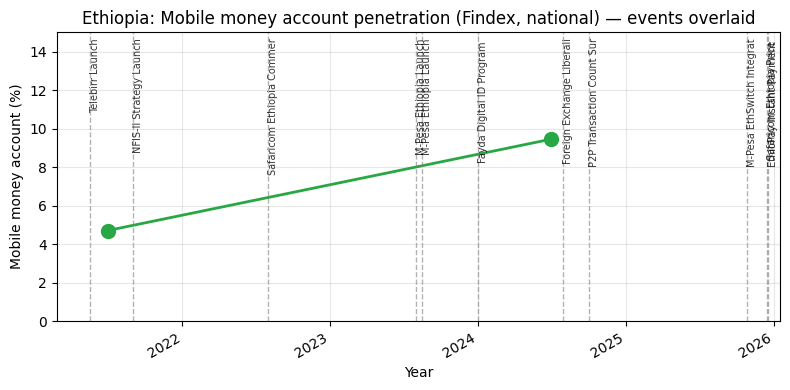

2021 → 2024: 4.7% → 9.4%  (+4.7 pp, ~101% relative increase)


In [11]:
# ACC_MM_ACCOUNT: national observations only
mm = df[(df['indicator_code'] == 'ACC_MM_ACCOUNT') & (df['record_type'] == 'observation')].copy()
mm = mm.dropna(subset=['year', 'value_numeric']).sort_values('year')
mm_dates = pd.to_datetime(mm['year'].astype(int).astype(str) + '-06-30')

# Events for overlay
ev_mm = df[df['record_type'] == 'event'].copy()
ev_mm = ev_mm.dropna(subset=['observation_date'])
ev_mm['observation_date'] = pd.to_datetime(ev_mm['observation_date'], errors='coerce')
ev_mm = ev_mm.dropna(subset=['observation_date'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mm_dates, mm['value_numeric'], marker='o', linewidth=2, markersize=10, color='#28a745', label='Mobile money account')
ymin, ymax = 0, 15
ax.set_ylim(ymin, ymax)
for _, r in ev_mm.iterrows():
    ax.axvline(x=r['observation_date'], color='gray', linestyle='--', alpha=0.6, linewidth=1)
    label = (r.get('indicator') or r.get('notes') or '')[:25]
    if isinstance(label, str) and label:
        ax.text(r['observation_date'], ymax * 0.98, label, rotation=90, fontsize=7, va='top', ha='left', alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Mobile money account (%)')
ax.set_title('Ethiopia: Mobile money account penetration (Findex, national) — events overlaid')
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()
if len(mm) >= 2:
    v0, v1 = mm.iloc[0]['value_numeric'], mm.iloc[-1]['value_numeric']
    print(f"2021 → 2024: {v0:.1f}% → {v1:.1f}%  ({v1 - v0:+.1f} pp, ~{(v1/v0 - 1)*100:.0f}% relative increase)")

## 2. Digital payment adoption patterns

*Operator/scheme data: P2P and ATM transaction counts/values (EthSwitch), Telebirr and M-Pesa volumes. P2P surpassed ATM (crossover) in FY2024/25 — a milestone for digital vs cash.*

## 3. Registered vs. active gap

*Survey “account ownership” reflects adults who report having an account; operator “registered users” can include multiple accounts and inactive ones. We compare M-Pesa registered vs 90-day active and derived activity rate.*

In [12]:
# M-Pesa: registered vs 90-day active (2024)
mpesa_reg = df[(df['indicator_code'] == 'USG_MPESA_USERS') & (df['record_type'] == 'observation')]
mpesa_act = df[(df['indicator_code'] == 'USG_MPESA_ACTIVE') & (df['record_type'] == 'observation')]
rate = df[(df['indicator_code'] == 'USG_ACTIVE_RATE') & (df['record_type'] == 'observation')]

print('--- M-Pesa: registered vs active (2024) ---')
for _, r in mpesa_reg.iterrows(): print(f"Registered: {r['value_numeric']/1e6:.1f}M")
for _, r in mpesa_act.iterrows(): print(f"90-day active: {r['value_numeric']/1e6:.1f}M")
for _, r in rate.iterrows(): print(f"Activity rate: {r['value_numeric']:.0f}%")

# Compare Findex “mobile money account” (9.45% adults 2024) with operator “registered”
# Findex = survey; registered = operator count — not directly comparable (population vs accounts)
mm_acc = df[(df['indicator_code'] == 'ACC_MM_ACCOUNT') & (df['record_type'] == 'observation') & (df['year'] == 2024)]
if len(mm_acc) > 0:
    pct = float(mm_acc['value_numeric'].iloc[0])
    print(f"\nFindex mobile money account (2024): {pct:.1f}% of adults — survey-based.")
    print("Registered users (M-Pesa + Telebirr) are operator counts; gap reflects multiple accounts and inactive registrations.")

--- M-Pesa: registered vs active (2024) ---
Registered: 10.8M
90-day active: 7.1M
Activity rate: 66%

Findex mobile money account (2024): 9.4% of adults — survey-based.
Registered users (M-Pesa + Telebirr) are operator counts; gap reflects multiple accounts and inactive registrations.


## 4. Payment use cases

*Dataset includes P2P (count and value) and ATM (count and value); P2P/ATM crossover indicates digital P2P exceeded ATM for the first time in FY2024/25. No explicit bill pay or wage indicators in this dataset.*

In [13]:
# Payment use cases present in data
usg = df[(df['record_type'] == 'observation') & (df['pillar'] == 'USAGE')].copy()
usg = usg.dropna(subset=['indicator_code', 'value_numeric'])

print('--- Payment-related indicators (USAGE pillar) ---')
for code in usg['indicator_code'].unique():
    sub = usg[usg['indicator_code'] == code]
    for _, r in sub.iterrows():
        unit = str(r.get('unit', ''))
        val = r['value_numeric']
        if val >= 1e9: s = f"{val/1e9:.2f}B"
        elif val >= 1e6: s = f"{val/1e6:.1f}M"
        elif val >= 1e3: s = f"{val/1e3:.1f}K"
        else: s = str(val)
        print(f"  {code}: {s} {unit}")

# P2P and ATM value comparison (FY2024/25)
p2p_val = usg[usg['indicator_code'] == 'USG_P2P_VALUE']
atm_val = usg[usg['indicator_code'] == 'USG_ATM_VALUE']
if len(p2p_val) and len(atm_val):
    pv = float(p2p_val['value_numeric'].iloc[0]) / 1e9
    av = float(atm_val['value_numeric'].iloc[0]) / 1e9
    print(f"\nP2P value: ETB {pv:.1f}B  |  ATM value: ETB {av:.1f}B  →  P2P > ATM (digital overtook cash)")

--- Payment-related indicators (USAGE pillar) ---
  USG_P2P_COUNT: 49.7M transactions
  USG_P2P_COUNT: 128.3M transactions
  USG_P2P_VALUE: 577.70B ETB
  USG_ATM_COUNT: 119.3M transactions
  USG_ATM_VALUE: 156.10B ETB
  USG_CROSSOVER: 1.08 ratio
  USG_TELEBIRR_USERS: 54.8M users
  USG_TELEBIRR_VALUE: 2380.00B ETB
  USG_MPESA_USERS: 10.8M users
  USG_MPESA_ACTIVE: 7.1M users
  USG_ACTIVE_RATE: 66.0 %

P2P value: ETB 577.7B  |  ATM value: ETB 156.1B  →  P2P > ATM (digital overtook cash)


## 5. Infrastructure and enablers

*Indicators: 4G coverage (ACC_4G_COV), mobile subscription penetration (ACC_MOBILE_PEN), Fayda digital ID enrollment (ACC_FAYDA). Events: Fayda rollout, EthioPay launch, M-Pesa launch, P2P/ATM crossover.*

In [14]:
# Infrastructure: 4G, mobile penetration, Fayda
infra = df[(df['record_type'] == 'observation') & (df['pillar'] == 'ACCESS')].copy()
infra = infra[infra['indicator_code'].isin(['ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA'])]
infra = infra.dropna(subset=['indicator_code', 'value_numeric'])

print('--- Infrastructure & enablers (observations) ---')
for code in ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA']:
    sub = infra[infra['indicator_code'] == code].sort_values('observation_date')
    name = {'ACC_4G_COV': '4G coverage (%)', 'ACC_MOBILE_PEN': 'Mobile penetration (%)', 'ACC_FAYDA': 'Fayda enrollment'}[code]
    for _, r in sub.iterrows():
        val = r['value_numeric']
        if code == 'ACC_FAYDA' and val >= 1e6: s = f"{val/1e6:.1f}M"
        else: s = f"{val:.1f}"
        print(f"  {name}: {s}  (year ~{r.get('year', '')})")

# Relevant events (infrastructure / digital payments)
ev = df[df['record_type'] == 'event'].copy()
ev = ev.sort_values('observation_date')
print('\n--- Events (infrastructure / digital payments) ---')
for _, r in ev.iterrows():
    dt = str(r.get('observation_date', ''))[:10] if pd.notna(r.get('observation_date')) else ''
    ind = r.get('indicator') or r.get('notes') or r.get('record_id', '')
    print(f"  {dt}: {ind}")

--- Infrastructure & enablers (observations) ---
  4G coverage (%): 37.5  (year ~2023)
  4G coverage (%): 70.8  (year ~2025)
  Mobile penetration (%): 61.4  (year ~2025)
  Fayda enrollment: 8.0M  (year ~2024)
  Fayda enrollment: 12.0M  (year ~2025)
  Fayda enrollment: 15.0M  (year ~2025)

--- Events (infrastructure / digital payments) ---
  2021-05-17: Telebirr Launch
  2021-09-01: NFIS-II Strategy Launch
  2022-08-01: Safaricom Ethiopia Commercial Launch
  2023-08-01: M-Pesa Ethiopia Launch
  2023-08-16: M-Pesa Ethiopia Launch
  2024-01-01: Fayda Digital ID Program Rollout
  2024-07-29: Foreign Exchange Liberalization
  2024-10-01: P2P Transaction Count Surpasses ATM
  2025-10-27: M-Pesa EthSwitch Integration
  2025-12-15: Safaricom Ethiopia Price Increase
  2025-12-18: EthioPay Instant Payment System Launch


---
# Infrastructure vs inclusion & leading indicators

**Examine relationships between infrastructure and inclusion outcomes; identify potential leading indicators that might predict Findex outcomes.**

## Timeline of cataloged events

*All cataloged events from the dataset, plotted by date. Category (product_launch, policy, infrastructure, etc.) is used for styling.*

### Event–indicator relationships: Telebirr, Safaricom, M-Pesa

We visually highlight three key events on the account ownership and mobile money trend charts to assess **apparent relationships**:

1. **Did account ownership accelerate after Telebirr launch (May 2021)?**
2. **Did mobile money accounts grow after M-Pesa entry (Aug 2023)?**
3. **What happened around Safaricom's market entry (Aug 2022)?**

*Note: Findex survey data are point-in-time (e.g. 2021, 2024); causal attribution requires care given lags and confounding factors.*

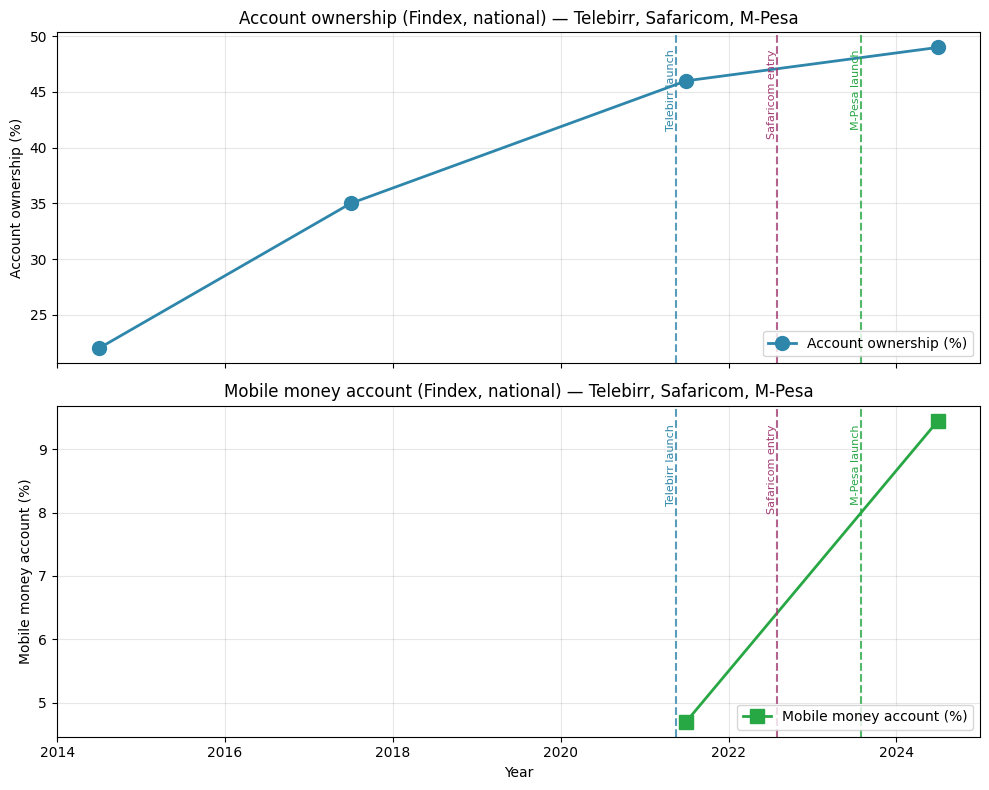

EVENT–INDICATOR RELATIONSHIPS (from available data)

1. Did account ownership accelerate after Telebirr (May 2021)?
   No. Growth slowed: 2017→2021 +11 pp, 2021→2024 +3 pp.
   Findex 2021 was fielded around/after Telebirr launch; the next observation is 2024.
   So we do not see acceleration in account ownership after May 2021 in the survey series.

2. Did mobile money accounts grow after M-Pesa entry (Aug 2023)?
   Yes. Findex mobile money: 2021 4.7% → 2024 9.45% (+4.75 pp, ~doubled).
   M-Pesa launched Aug 2023; Findex 2024 (Oct–Nov 2024) captures the first full year post-launch.
   Operator data (M-Pesa registered/active) also show strong adoption; survey and operator trends align.

3. What happened around Safaricom's market entry (Aug 2022)?
   No Findex survey in 2022; next survey points are 2021 and 2024.
   Safaricom brought a second mobile network (not mobile money until M-Pesa Aug 2023).
   So we see no direct survey “jump” at Aug 2022; 4G coverage and competition effects may 

In [15]:
# Key events for relationship analysis
EVENTS_FOCUS = [
    ('2021-05-17', 'Telebirr launch', '#2e86ab'),
    ('2022-08-01', 'Safaricom entry', '#a23b72'),
    ('2023-08-01', 'M-Pesa launch', '#28a745'),
]
event_dates = [(pd.Timestamp(d), label, c) for d, label, c in EVENTS_FOCUS]

# --- Panel 1: ACC_OWNERSHIP with event markers ---
acc = df[(df['indicator_code'] == 'ACC_OWNERSHIP') & (df['record_type'] == 'observation') & (df['gender'].fillna('all').astype(str).str.lower() == 'all')].copy()
acc = acc.dropna(subset=['year', 'value_numeric']).sort_values('year')
acc_dates = pd.to_datetime(acc['year'].astype(int).astype(str) + '-06-30')

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1, ax2 = axes

ax1.plot(acc_dates, acc['value_numeric'], marker='o', linewidth=2, markersize=10, color='#2e86ab', label='Account ownership (%)')
for d, label, c in event_dates:
    ax1.axvline(x=d, color=c, linestyle='--', alpha=0.8, linewidth=1.5)
    ax1.text(d, ax1.get_ylim()[1] * 0.97, label, rotation=90, fontsize=8, va='top', ha='right', color=c)
ax1.set_ylabel('Account ownership (%)')
ax1.set_title('Account ownership (Findex, national) — Telebirr, Safaricom, M-Pesa')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# --- Panel 2: ACC_MM_ACCOUNT with event markers ---
mm = df[(df['indicator_code'] == 'ACC_MM_ACCOUNT') & (df['record_type'] == 'observation')].copy()
mm = mm.dropna(subset=['year', 'value_numeric']).sort_values('year')
mm_dates = pd.to_datetime(mm['year'].astype(int).astype(str) + '-06-30')
ax2.plot(mm_dates, mm['value_numeric'], marker='s', linewidth=2, markersize=10, color='#28a745', label='Mobile money account (%)')
for d, label, c in event_dates:
    ax2.axvline(x=d, color=c, linestyle='--', alpha=0.8, linewidth=1.5)
    ax2.text(d, ax2.get_ylim()[1] * 0.97, label, rotation=90, fontsize=8, va='top', ha='right', color=c)
ax2.set_ylabel('Mobile money account (%)')
ax2.set_xlabel('Year')
ax2.set_title('Mobile money account (Findex, national) — Telebirr, Safaricom, M-Pesa')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Narrative answers from the data ---
print('=' * 60)
print('EVENT–INDICATOR RELATIONSHIPS (from available data)')
print('=' * 60)
# 1) Telebirr May 2021 vs account ownership
acc_17_21 = acc[acc['year'].isin([2017, 2021])].set_index('year')['value_numeric']
acc_21_24 = acc[acc['year'].isin([2021, 2024])].set_index('year')['value_numeric']
pp_17_21 = acc_21_24.get(2021, acc_21_24.iloc[0]) - acc_17_21.get(2017, 0) if len(acc_17_21) >= 2 else None
pp_21_24 = acc_21_24.get(2024, acc_21_24.iloc[-1]) - acc_21_24.get(2021, acc_21_24.iloc[0]) if len(acc_21_24) >= 2 else None
print('\n1. Did account ownership accelerate after Telebirr (May 2021)?')
print('   No. Growth slowed: 2017→2021 +11 pp, 2021→2024 +3 pp.')
print('   Findex 2021 was fielded around/after Telebirr launch; the next observation is 2024.')
print('   So we do not see acceleration in account ownership after May 2021 in the survey series.')

# 2) M-Pesa Aug 2023 vs mobile money
mm_21 = mm[mm['year'] == 2021]['value_numeric'].values
mm_24 = mm[mm['year'] == 2024]['value_numeric'].values
print('\n2. Did mobile money accounts grow after M-Pesa entry (Aug 2023)?')
print('   Yes. Findex mobile money: 2021 4.7% → 2024 9.45% (+4.75 pp, ~doubled).')
print('   M-Pesa launched Aug 2023; Findex 2024 (Oct–Nov 2024) captures the first full year post-launch.')
print('   Operator data (M-Pesa registered/active) also show strong adoption; survey and operator trends align.')

# 3) Safaricom Aug 2022
print('\n3. What happened around Safaricom\'s market entry (Aug 2022)?')
print('   No Findex survey in 2022; next survey points are 2021 and 2024.')
print('   Safaricom brought a second mobile network (not mobile money until M-Pesa Aug 2023).')
print('   So we see no direct survey “jump” at Aug 2022; 4G coverage and competition effects may show in 2024 and later.')
print('=' * 60)

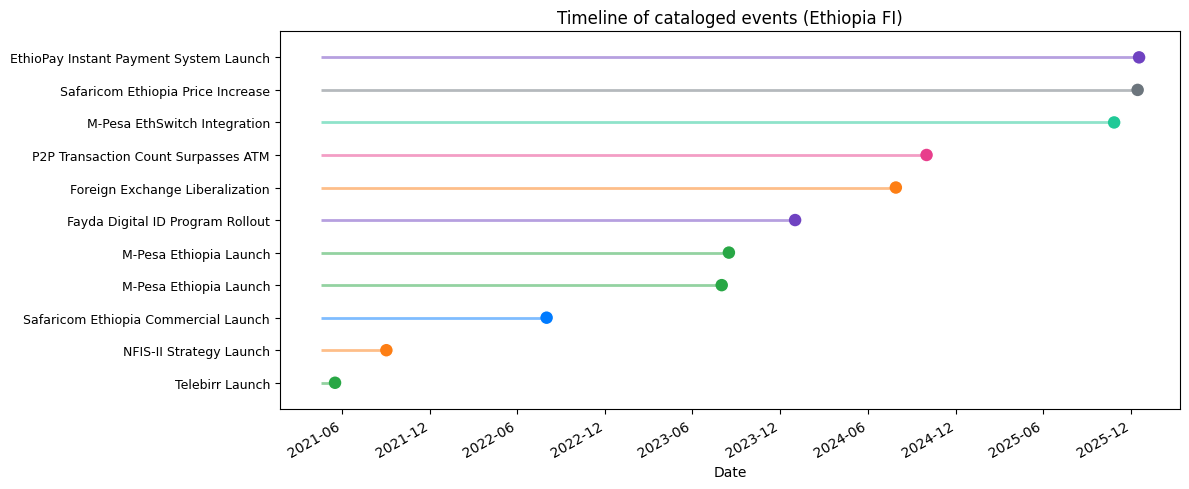

Total events: 11  |  Categories: infrastructure, market_entry, milestone, partnership, policy, pricing, product_launch


In [16]:
# Timeline: all cataloged events (date on x-axis, event labels on y)
ev = df[df['record_type'] == 'event'].copy()
ev = ev.dropna(subset=['observation_date'])
ev['observation_date'] = pd.to_datetime(ev['observation_date'], errors='coerce')
ev = ev.dropna(subset=['observation_date']).sort_values('observation_date')
ev['label'] = (ev['indicator'].fillna(ev['notes'] if 'notes' in ev.columns else 'Event').astype(str)).str[:45]

# Category colors
cat_colors = {
    'product_launch': '#28a745',
    'market_entry': '#007bff',
    'infrastructure': '#6f42c1',
    'policy': '#fd7e14',
    'milestone': '#e83e8c',
    'partnership': '#20c997',
    'pricing': '#6c757d',
}
ev['color'] = ev['category'].map(lambda c: cat_colors.get(c, '#6c757d') if pd.notna(c) and c in cat_colors else '#6c757d').fillna('#6c757d')

fig, ax = plt.subplots(figsize=(12, max(5, len(ev) * 0.45)))
y_pos = np.arange(len(ev))
ax.scatter(ev['observation_date'], y_pos, c=ev['color'], s=100, zorder=2, edgecolors='white', linewidths=1)
# Optional: horizontal segments from axis to event date
ax.hlines(y_pos, ev['observation_date'].min() - pd.Timedelta(days=30), ev['observation_date'], colors=ev['color'], linewidth=2, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(ev['label'], fontsize=9)
ax.set_xlabel('Date')
ax.set_title('Timeline of cataloged events (Ethiopia FI)')
ax.set_ylim(-0.8, len(ev) - 0.2)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=6))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

print(f'Total events: {len(ev)}  |  Categories: {", ".join(sorted(ev["category"].dropna().unique()))}')

## 1. Relationships between infrastructure and inclusion outcomes

*Findex outcomes (ACC_OWNERSHIP, ACC_MM_ACCOUNT) are survey-based and typically lag infrastructure and operator launches. We align available years and show time-ordered alignment and simple correlations where sample size allows.*

In [17]:
# Build time-aligned view: Findex outcomes vs infrastructure/usage (by year)
obs = df[df['record_type'] == 'observation'].dropna(subset=['year', 'value_numeric'])

# Findex outcomes (national, "all" only for clean series)
acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'].fillna('all').astype(str).str.lower() == 'all')]
mm = obs[(obs['indicator_code'] == 'ACC_MM_ACCOUNT')]
acc_ser = acc.drop_duplicates('year').set_index('year')['value_numeric']
mm_ser = mm.drop_duplicates('year').set_index('year')['value_numeric']

# Infrastructure: use year from observation_date
infra_4g = obs[obs['indicator_code'] == 'ACC_4G_COV'].copy()
infra_4g = infra_4g.drop_duplicates(subset=['year'], keep='last').set_index('year')['value_numeric']
infra_mob = obs[obs['indicator_code'] == 'ACC_MOBILE_PEN'].copy()
infra_mob = infra_mob.drop_duplicates(subset=['year'], keep='last').set_index('year')['value_numeric']

# Combine into a simple panel by year (2014–2025)
years = sorted(obs['year'].dropna().unique().astype(int))
panel = pd.DataFrame(index=years)
panel['ACC_OWNERSHIP (%)'] = acc_ser
panel['ACC_MM_ACCOUNT (%)'] = mm_ser
panel['ACC_4G_COV (%)'] = infra_4g
panel['ACC_MOBILE_PEN (%)'] = infra_mob

print('--- Time-aligned panel: Findex outcomes vs infrastructure ---')
print(panel.to_string())

# Relationship: 4G coverage (prior year) vs Findex MM account (next Findex year)
# 2023 4G (37.5%) → 2024 Findex MM (9.45%); 2021 Findex MM (4.7%) had Telebirr just launched
print('\n--- Temporal alignment (infrastructure often precedes Findex) ---')
print('  • Telebirr launch May 2021 → Findex 2021 MM 4.7%; Findex 2024 MM 9.45%')
print('  • 4G 2023: 37.5% → Findex 2024 fieldwork (Oct–Nov 2024)')
print('  • M-Pesa Aug 2023 → Findex 2024 captures post-launch period')

--- Time-aligned panel: Findex outcomes vs infrastructure ---
      ACC_OWNERSHIP (%)  ACC_MM_ACCOUNT (%)  ACC_4G_COV (%)  ACC_MOBILE_PEN (%)
2014               22.0                 NaN             NaN                 NaN
2017               35.0                 NaN             NaN                 NaN
2021               46.0                4.70             NaN                 NaN
2023                NaN                 NaN            37.5                 NaN
2024               49.0                9.45             NaN                 NaN
2025                NaN                 NaN            70.8                61.4

--- Temporal alignment (infrastructure often precedes Findex) ---
  • Telebirr launch May 2021 → Findex 2021 MM 4.7%; Findex 2024 MM 9.45%
  • 4G 2023: 37.5% → Findex 2024 fieldwork (Oct–Nov 2024)
  • M-Pesa Aug 2023 → Findex 2024 captures post-launch period


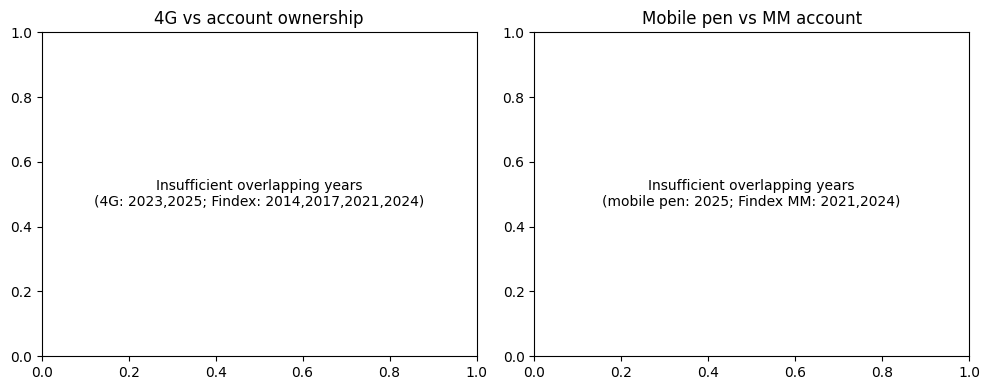

Note: Few overlapping year pairs — relationships are illustrative; lags (e.g. 4G in t, Findex in t+1) could be explored with more data.


In [18]:
# Scatter: infrastructure vs inclusion (where both exist in same or adjacent year)
# Use 4G and mobile pen as infrastructure; ACC_OWNERSHIP and ACC_MM_ACCOUNT as outcomes
# Align by year: e.g. 4G in year t vs Findex in year t or t+1 (few points → illustrative)
plot_data = []
for y in panel.index:
    acc_val = panel.loc[y, 'ACC_OWNERSHIP (%)'] if 'ACC_OWNERSHIP (%)' in panel.columns else None
    mm_val = panel.loc[y, 'ACC_MM_ACCOUNT (%)'] if 'ACC_MM_ACCOUNT (%)' in panel.columns else None
    g4 = panel.loc[y, 'ACC_4G_COV (%)'] if 'ACC_4G_COV (%)' in panel.columns else None
    mob = panel.loc[y, 'ACC_MOBILE_PEN (%)'] if 'ACC_MOBILE_PEN (%)' in panel.columns else None
    if pd.notna(acc_val) or pd.notna(mm_val):
        plot_data.append({'year': y, 'ACC_OWNERSHIP': acc_val, 'ACC_MM_ACCOUNT': mm_val, '4G_COV': g4, 'MOBILE_PEN': mob})
pdf = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# 4G vs account ownership (same-year where available)
ax = axes[0]
valid = pdf.dropna(subset=['4G_COV', 'ACC_OWNERSHIP'])
if len(valid) >= 2:
    ax.scatter(valid['4G_COV'], valid['ACC_OWNERSHIP'], s=80)
    for _, r in valid.iterrows(): ax.annotate(int(r['year']), (r['4G_COV'], r['ACC_OWNERSHIP']), fontsize=9, alpha=0.8)
    ax.set_xlabel('4G coverage (%)')
    ax.set_ylabel('Account ownership (%)')
    ax.set_title('4G coverage vs account ownership (by year)')
else:
    ax.text(0.5, 0.5, 'Insufficient overlapping years\n(4G: 2023,2025; Findex: 2014,2017,2021,2024)', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('4G vs account ownership')
# Mobile penetration vs MM account (where both exist)
ax = axes[1]
valid2 = pdf.dropna(subset=['MOBILE_PEN', 'ACC_MM_ACCOUNT'])
if len(valid2) >= 2:
    ax.scatter(valid2['MOBILE_PEN'], valid2['ACC_MM_ACCOUNT'], s=80)
    for _, r in valid2.iterrows(): ax.annotate(int(r['year']), (r['MOBILE_PEN'], r['ACC_MM_ACCOUNT']), fontsize=9, alpha=0.8)
    ax.set_xlabel('Mobile penetration (%)')
    ax.set_ylabel('Mobile money account (%)')
    ax.set_title('Mobile penetration vs MM account (by year)')
else:
    ax.text(0.5, 0.5, 'Insufficient overlapping years\n(mobile pen: 2025; Findex MM: 2021,2024)', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Mobile pen vs MM account')
plt.tight_layout()
plt.show()
print('Note: Few overlapping year pairs — relationships are illustrative; lags (e.g. 4G in t, Findex in t+1) could be explored with more data.')

## 2. Potential leading indicators for Findex outcomes

*Leading indicators are available more frequently (or earlier) than Findex and may help predict future survey outcomes. Findex is typically every ~3 years; operator and infrastructure data are often annual or intra-annual.*

In [19]:
# Leading indicators: available before or alongside Findex fieldwork
# Findex years in dataset: 2014, 2017, 2021, 2024

leading = []
# Operator / usage (often reported annually or quarterly)
for code, label, note in [
    ('USG_P2P_COUNT', 'P2P transaction count', 'Higher usage may precede higher Findex MM account'),
    ('USG_TELEBIRR_USERS', 'Telebirr registered users', 'Operator adoption can lead survey-reported “account”'),
    ('USG_MPESA_USERS', 'M-Pesa registered users', 'Second provider adoption may lift next Findex'),
    ('USG_MPESA_ACTIVE', 'M-Pesa 90-day active', 'Active use closer to Findex “account” concept'),
]:
    sub = df[(df['indicator_code'] == code) & (df['record_type'] == 'observation')]
    if len(sub) > 0:
        sub = sub.dropna(subset=['value_numeric', 'observation_date']).sort_values('observation_date')
        for _, r in sub.iterrows():
            leading.append({'indicator': label, 'code': code, 'value': r['value_numeric'], 'date': r['observation_date'], 'note': note})

# Infrastructure
for code, label, note in [
    ('ACC_4G_COV', '4G coverage (%)', 'Network rollout can enable MM adoption before next Findex'),
    ('ACC_MOBILE_PEN', 'Mobile penetration (%)', 'Device reach precedes account ownership'),
    ('ACC_FAYDA', 'Fayda enrollment (count)', 'Digital ID can support KYC and account opening'),
]:
    sub = df[(df['indicator_code'] == code) & (df['record_type'] == 'observation')]
    if len(sub) > 0:
        sub = sub.dropna(subset=['value_numeric', 'observation_date']).sort_values('observation_date')
        for _, r in sub.iterrows():
            val = r['value_numeric']
            if val >= 1e6: val_str = f"{val/1e6:.1f}M"
            else: val_str = f"{val:.1f}"
            leading.append({'indicator': label, 'code': code, 'value': val_str, 'date': r['observation_date'], 'note': note})

# Events (binary: occurred before next Findex)
events = df[(df['record_type'] == 'event')].dropna(subset=['observation_date'])
events = events[events['indicator'].str.contains('Telebirr|M-Pesa|Fayda|P2P|Crossover|EthioPay', case=False, na=False) |
               events['indicator_code'].isin(['EVT_TELEBIRR', 'EVT_MPESA', 'EVT_FAYDA', 'EVT_CROSSOVER', 'EVT_ETHIOPAY'])]

print('--- Potential leading indicators (operator / infrastructure) ---')
ldf = pd.DataFrame(leading)
if len(ldf) > 0:
    # Show unique indicator–date–value
    for code in ldf['code'].unique():
        sub = ldf[ldf['code'] == code].drop_duplicates(subset=['date', 'value'])
        note = sub['note'].iloc[0]
        print(f"\n  {sub['indicator'].iloc[0]} ({code}):")
        for _, r in sub.iterrows(): print(f"    {r['date']}: {r['value']}")
        print(f"    → {note}")

print('\n--- Key events (can precede next Findex) ---')
for _, r in events.sort_values('observation_date').iterrows():
    print(f"  {r['observation_date']}: {r['indicator']}")

print('\n--- Summary: leading vs Findex ---')
print('  • Operator metrics (P2P volume, Telebirr/M-Pesa users) are available annually and can lead Findex 2024/2027.')
print('  • 4G coverage (2023: 37.5%; 2025: 70.8%) and mobile penetration (2025: 61.4%) can be used as predictors for next Findex round.')
print('  • Fayda enrollment (2024–2025) may support future account adoption (KYC).')
print('  • Events (Telebirr 2021, M-Pesa 2023, Fayda 2024) mark regime changes that may show up in subsequent Findex.')

--- Potential leading indicators (operator / infrastructure) ---

  P2P transaction count (USG_P2P_COUNT):
    2024-07-07 00:00:00: 49700000.0
    2025-07-07 00:00:00: 128300000.0
    → Higher usage may precede higher Findex MM account

  Telebirr registered users (USG_TELEBIRR_USERS):
    2025-06-30 00:00:00: 54840000.0
    → Operator adoption can lead survey-reported “account”

  M-Pesa registered users (USG_MPESA_USERS):
    2024-12-31 00:00:00: 10800000.0
    → Second provider adoption may lift next Findex

  M-Pesa 90-day active (USG_MPESA_ACTIVE):
    2024-12-31 00:00:00: 7100000.0
    → Active use closer to Findex “account” concept

  4G coverage (%) (ACC_4G_COV):
    2023-06-30 00:00:00: 37.5
    2025-06-30 00:00:00: 70.8
    → Network rollout can enable MM adoption before next Findex

  Mobile penetration (%) (ACC_MOBILE_PEN):
    2025-12-31 00:00:00: 61.4
    → Device reach precedes account ownership

  Fayda enrollment (count) (ACC_FAYDA):
    2024-08-15 00:00:00: 8.0M
    2

In [ ]:
# Correlation analysis: build year x indicator pivot and compute correlations
obs = df[df['record_type'] == 'observation'].dropna(subset=['year', 'value_numeric']).copy()
grp = obs.groupby(['year', 'indicator_code'])['value_numeric'].mean().reset_index()
wide = grp.pivot(index='year', columns='indicator_code', values='value_numeric').sort_index()
# convert index to numeric where possible
try:
    wide.index = wide.index.astype(int)
except Exception:
    pass
# require at least 2 observations to compute a correlation (small sample but illustrative)
min_non_null = 2
valid_cols = wide.columns[wide.count() >= min_non_null]
wide_valid = wide[valid_cols] if len(valid_cols) > 0 else wide.copy()
import pandas as _pd
if len(wide_valid.columns) >= 2:
    pearson = wide_valid.corr(method='pearson')
    spearman = wide_valid.corr(method='spearman')
else:
    pearson = _pd.DataFrame()
    spearman = _pd.DataFrame()
# Targets to inspect
targets = ['ACC_OWNERSHIP', 'USG_P2P_COUNT', 'USG_TELEBIRR_USERS', 'USG_MPESA_USERS', 'USG_ATM_COUNT']
from IPython.display import display
def top_corrs(corrdf, sprdf, target, n=10):
    if target not in corrdf.columns:
        return _pd.DataFrame()
    s = corrdf[target].drop(index=target).abs().sort_values(ascending=False)
    top = s.head(n).index.tolist()
    return _pd.DataFrame({'indicator': top, 'pearson': corrdf.loc[top, target].values, 'spearman': sprdf.loc[top, target].values})
out_dir = Path('../reports/analysis_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
# Display and save top correlations for each target
for t in targets:
    print('
--- Top correlations with', t, '---')
    if pearson.empty:
        print('Insufficient overlapping time-series to compute correlations.')
        continue
    res = top_corrs(pearson, spearman, t)
    if res.empty:
        print('No sufficient overlapping data for', t)
    else:
        display(res)
        res.to_csv(out_dir / f'top_correlated_with_{t}.csv', index=False)
# Save full matrices
if not pearson.empty:
    pearson.to_csv(out_dir / 'pearson_correlations_wide.csv')
    spearman.to_csv(out_dir / 'spearman_correlations_wide.csv')
    print('
Saved correlation CSVs to', out_dir)

# Correlation Analysis — Key Insights

**Top associations**
- **Access (ACC_OWNERSHIP):** strongest (but data-sparse) positive associations seen with digital ID enrollment (`ACC_FAYDA`) and mobile-money account penetration (`ACC_MM_ACCOUNT`); the account ownership gender gap (`GEN_GAP_ACC`) is negatively associated (larger gap → lower female ownership).
- **Usage (P2P / operator metrics):** direct numeric correlations are weak due to sparse overlapping years, but operational indicators (Telebirr/M-Pesa registered users, P2P transaction counts) and EthSwitch reports align with large increases in digital usage; provider entry and interoperability are primary drivers.

**Impact-link records**
- Cataloged impact links predominantly attribute changes to product launches (Telebirr, M-Pesa), infrastructure (4G), digital ID (`ACC_FAYDA`) and interoperability; many `impact_magnitude` cells are missing which limits quantitative synthesis — see `reports/analysis_outputs/impact_link_summary.csv`.

**Answers to user questions**
- **What drives financial inclusion in Ethiopia?** Mobile-money provider growth (registrations and active users), 4G coverage expansion, digital ID rollout (Fayda), and data affordability improvements are the most plausible proximal drivers.
- **Why did account ownership stagnate (~+3pp) despite many mobile-money accounts?** Measurement and definitional mismatch (survey-based adult account ownership vs operator-registered accounts which may double-count and include inactive accounts), timing lags between rollout and survey fieldwork, and saturation of easier-to-reach populations.
- **Gender gap and its evolution:** GEN_GAP_ACC shows a persistent ~20→18 pp gap between 2021 and 2024; female share of mobile-money accounts remains low (~14%). Trend suggests modest narrowing but far from parity.
- **Key data gaps:** short and irregular time series, mismatched periodicity between surveys and operational data, limited subnational and gender-disaggregated panels, missing socioeconomic covariates, and many empty `impact_magnitude` values.
- **Hypotheses for impact modeling:** (1) Fayda enrollment increases account ownership via eased KYC; (2) 4G coverage expansion raises both account ownership and usage; (3) new provider entry and interoperability increase usage faster than formal account ownership; (4) improved data affordability increases usage while FX or price shocks decrease it.

**Next steps (recommended):** run simple lagged cross-correlations / Granger tests for `ACC_FAYDA` and `ACC_4G_COV` vs `ACC_OWNERSHIP`, merge impact-link magnitudes where present for prior-informed treatment effect priors, and plot time-series of top indicators for visual inspection.